<a href="https://colab.research.google.com/github/BrantisIsHacking/Boston-Asian-Food-Reviews-Sentiment-Analysis/blob/main/Vestibular%20Problem%20Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview

## *The Problem*

Physicians need a way to better assess concussions (i.e. determine the sub-type of concussion) so that they can determine how to prescribe the best treatment possible.

## *Proposed Solution*

Produce an ML model using eye-tracking data collected by an EyeBOX exam and clinically-collected VVE (Visio Vestibular Examination) that can determine if a concussion patient has vestibular problems based on eye-tracking alone.

## *MVP*

- Training script(s) - takes the input training data (VVE and eye-tracking time series) and produces a model to be used by the prediction script(s)
- Prediction script(s) - takes a new unseen eye-tracking scan and produces a score or similar output to predict if that person has vestibular issues.
- A report that includes the performance (sensitivity, specificity, confidence intervals, and other statistics) of the training set, ideally using appropriate cross-validation and/or hold-out set.

## *Success Criteria*

- The cross-validated performance of the model has a sensitivity of at least 0.75 and specificity at least 0.75.
- The prediction script runs in less than 10 seconds per eye-tracking scan on an average powered Windows computer.

# Data Visualization and Pre-Processing

1.   Handling empty data values
2.   Identifying extraneous features
3.   Separating patient data into samples for training


## *Correlation Matrix*

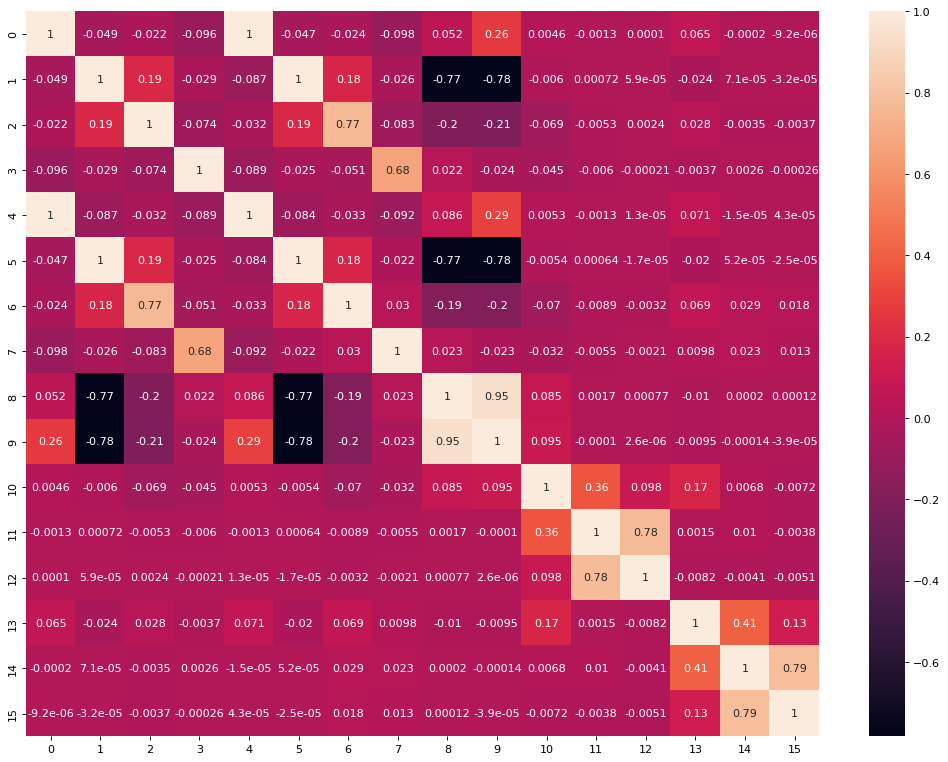

There seem to be direct correlations betweeen the left and right eye data(our bodies naturally move each eye the same way to help focus on the same object).

There are also similar correlations between radial velocity, acceleration, and jerk, which make sense because all are derivations of each other.

Due to possible concerns about overfitting, it may be optimal to remove certain repetitive features.

## *Pi Charts*

Distribution of data at a threshold of 3 out of 9:

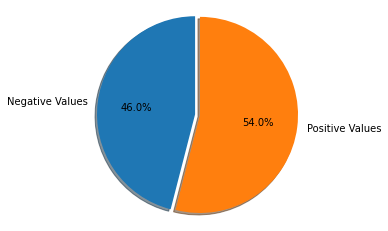

Distribution of data at a threshold of 4 out of 9:

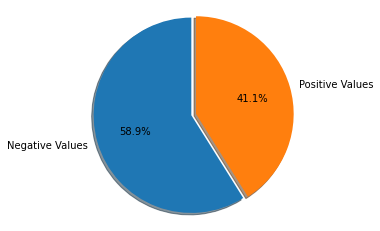

Distribution of data at a threshold of 5 out of 9:

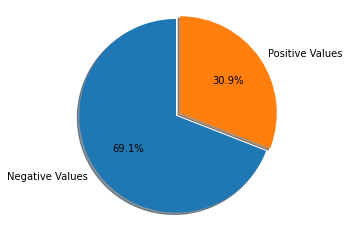

## *Data Pre-processing*

The data was given in CSV files for each patient, with a large master CSV file containing the physician's evaluation of each concussion patient. Therefore, the steps to pre-process the data were:



1.   Match each patient's CSV file with their physician's diagnosis in the master CSV file.
2.   Remove empty data cells.
3.   Divide each patient into samples of 25k data points(most CSV files contained up to 100k points).
4.   Split into train-test datasets.
5.   Save as numpy arrays.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from os import path
from sklearn.linear_model import RidgeClassifierCV
from sktime.transformations.panel.rocket import MiniRocketMultivariate
import pickle
import random
!pip install sktime

sampleLength =25000
concussionThreshold_upper = 3
concussionThreshold_lower = 2
numFeatures = 6
dataTestingPercent = .3
stepSize = 2

filePath = '/content/drive/MyDrive/Oculogica/Data/'
savePath = '/content/drive/MyDrive/threshold2/'
fileCount = 0
numTrainingSets=153
positiveSamples = []
negativeSamples = []
xTestList = []
yTestList = []

vve = pd.read_csv("/content/drive/MyDrive/Oculogica/VVE-clinical-devset.csv")
for index, row in vve.iterrows():
    fileName = row['ScanFileName']
    fnLen = len(fileName)
    modFileName = fileName[0:fnLen-4] + "_norm.csv"
    scanFile = filePath + modFileName
    if path.exists(scanFile):
      fileCount+=1
        # read a csv scan file
      scanContent = pd.read_csv(scanFile)
      scanContent = scanContent[::stepSize]

      # extract samples from columns LeftX, LeftY, RightX, RightY
      featureFrame = scanContent[['LeftX', 'LeftY', 'RightX', 'RightY','LeftPupilRadius', 'RightPupilRadius' ]].copy().dropna()
      numScanRows = featureFrame.shape[0]

      if fileCount<=numTrainingSets:
        # loop over the scan and extract as many samples as possible
        for i in range(0, numScanRows-sampleLength, sampleLength):
          xSample= featureFrame.iloc[i:i+sampleLength, :]
          # check whether this is a pos or neg sample
          if row['VVE_NumMeasuresAbnormal'] >= concussionThreshold_upper:
              # add the scan sample to the list of positive training samples
              positiveSamples.append(xSample.to_numpy())
          elif row['VVE_NumMeasuresAbnormal'] < concussionThreshold_lower:
              # add the scan sample to the list of negative training samples
              negativeSamples.append(xSample.to_numpy())
      else:
        if row['VVE_NumMeasuresAbnormal']<concussionThreshold_lower:
          yTestList.append(0)
          xTestList.append(scanContent)
        elif row['VVE_NumMeasuresAbnormal']>=concussionThreshold_upper:
          yTestList.append(1)
          xTestList.append(scanContent)
    else:
        print("Missing scan file: " + scanFile + "\n")

numPositiveSamples = len(positiveSamples)
numNegativeSamples = len(negativeSamples)

posIdx = list(range(0, numPositiveSamples))
random.shuffle(posIdx)


negIdx = list(range(0, numNegativeSamples))
random.shuffle(negIdx)

sampleCount= numPositiveSamples+numNegativeSamples
xData = np.zeros((2*sampleCount, sampleLength, numFeatures))
yData = np.zeros((2*sampleCount, 1))
for i in range(0,numPositiveSamples):
  xData[i*2,0:sampleLength,0:numFeatures] = positiveSamples[posIdx[i]]
  yData[i*2, 0] = 1
for i in range(0, numNegativeSamples):
    xData[i*2+1,0:sampleLength,0:numFeatures] = negativeSamples[negIdx[i]]
    yData[i*2+1, 0] = 0


# scale xData by 0.1 to get the data into the approximate range -1 to +1
xData *= 0.1


In [ ]:
sampleLength = 25000
numFeatures = 6
stepSize = 1
fileCount = 0
tempX=[]
#scanContent=pd.read_csv('/content/drive/MyDrive/Oculogica/Data/12-07-2018-185131_norm.csv')
scanContent=pd.read_csv('/content/drive/MyDrive/Oculogica/Data/14102412_norm.csv')
scanContent = scanContent[::stepSize]
# extract samples from columns LeftX, LeftY, RightX, RightY
featureFrame = scanContent[['LeftX', 'LeftY', 'RightX', 'RightY','LeftPupilRadius', 'RightPupilRadius']].copy().dropna()
numScanRows = featureFrame.shape[0]
numTrainingRows = numScanRows/stepSize
# loop over the scan and extract as many samples as possible
for i in range(0, numScanRows-sampleLength, int(sampleLength/4)):
    xSample= featureFrame.iloc[i:i+sampleLength, :]
    tempX.append(xSample.to_numpy())
index = list(range(0, len(tempX)))
random.shuffle(index)
sampleCount=len(tempX)
xData = np.zeros((sampleCount, sampleLength, numFeatures))
for i in range(0,sampleCount):
    xData[i,0:sampleLength,0:numFeatures] = tempX[index[i]]

# scale xData by 0.1 to get the data into the approximate range -1 to +1
xData *= 0.1
testX = np.transpose(xData, [0, 2, 1])
with open('/content/drive/MyDrive/threshold/oculogia-rocketModel_classifier_v2.pkl', 'rb') as f:
  classifier=pickle.load(f)
with open('/content/drive/MyDrive/threshold/oculogia-rocketModel_minirocket_v2.pkl', 'rb') as f:
  minirocket=pickle.load(f)
input=minirocket.transform(np.array(testX))
prediction=classifier.predict(input)
predictTrue=0
predictFalse=0
for i in prediction:
    if i==1:
        predictTrue+=1
    elif i==0:
        predictFalse+=1
if predictTrue>=predictFalse:
    print("Because there are "+str(predictTrue)+" positives and "+str(predictFalse)+" negatives, the model outputs yes")
else:
    print("Because there are "+str(predictTrue)+" positives and "+str(predictFalse)+" negatives, the model outputs no")

Because there are 2 positives and 8 negatives, the model outputs no
